In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [ ]:
crimes_df=pd.read_csv("data/estimated_crimes_1979_2023.csv")
# این داده ها مربوط به نرخ جرایم در آمریکا است 

In [3]:
crimes_df.drop(columns=["state_abbr","rape_legacy"],inplace=True)

In [4]:
crimes_df=crimes_df[(crimes_df["year"]>=2013) & (crimes_df["year"]<=2022)]

In [5]:
crimes_df.isnull().sum()

year                   0
state_name             4
population             0
violent_crime          0
homicide               0
rape_revised           0
robbery                0
aggravated_assault     0
property_crime         0
burglary               0
larceny                0
motor_vehicle_theft    0
dtype: int64

In [6]:
crimes_df.rename(columns={"state_name":"state","rape_revised":"rape"},inplace=True)

In [7]:
crimes_df.dropna(inplace=True)

In [8]:
crimes_df.info()
# با توجه به اینکه 10 سال در51 ایالت باید 510 سطر به ما بدهد، دو داده اضافه وجود دارد

<class 'pandas.core.frame.DataFrame'>
Index: 512 entries, 1769 to 2283
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   year                 512 non-null    int64 
 1   state                512 non-null    object
 2   population           512 non-null    object
 3   violent_crime        512 non-null    object
 4   homicide             512 non-null    object
 5   rape                 512 non-null    object
 6   robbery              512 non-null    object
 7   aggravated_assault   512 non-null    object
 8   property_crime       512 non-null    object
 9   burglary             512 non-null    object
 10  larceny              512 non-null    object
 11  motor_vehicle_theft  512 non-null    object
dtypes: int64(1), object(11)
memory usage: 52.0+ KB


In [9]:
cols=["population", "violent_crime", "homicide", "rape", "robbery", "aggravated_assault", "property_crime", "burglary", "larceny", "motor_vehicle_theft"]
for i in cols:
    crimes_df[i]=crimes_df[i].str.replace(",", "", regex=False)
    crimes_df[i]=pd.to_numeric(crimes_df[i], errors="coerce")

In [10]:
crimes_df.reset_index(drop=True,inplace=True)

In [11]:
crimes_df2=crimes_df.drop(columns=["homicide", "rape", "robbery", "aggravated_assault", "burglary", "larceny", "motor_vehicle_theft"])

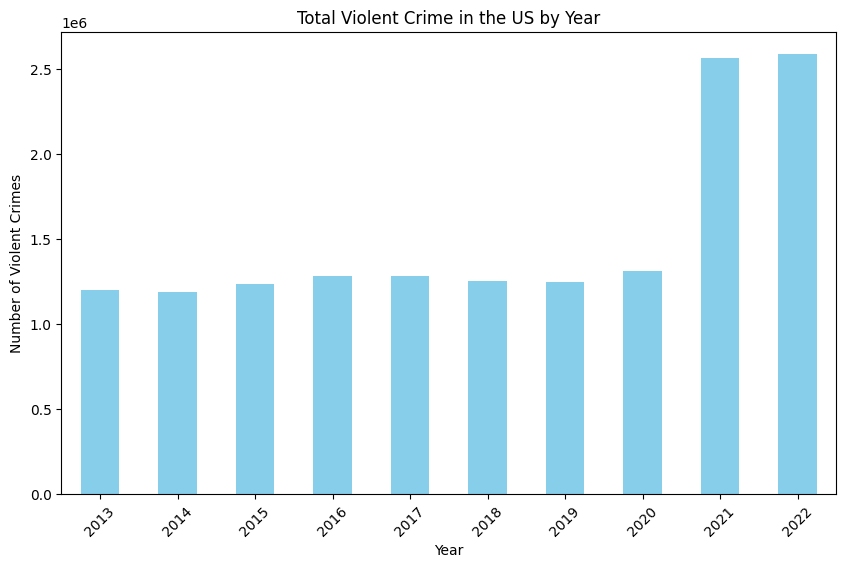

In [12]:
yearly_violent=crimes_df2.groupby("year")["violent_crime"].sum()
plt.figure(figsize=(10,6))
yearly_violent.plot(kind="bar", color="skyblue")
plt.title("Total Violent Crime in the US by Year")
plt.xlabel("Year")
plt.ylabel("Number of Violent Crimes")
plt.xticks(rotation=45)
plt.show()
# میزان جرم در دو سال آخر دو و نیم برابره که غیرممکنه 
#پس فهمیدم داده های اضافه باید در این دوسال وجود داشته باشند
# در این دو سال کشورآمریکا به طور کلی هم به داده ها اضافه شده بود
# در ادامه این دو داده رو حذف کردم

In [13]:
index_to_drop=crimes_df2[crimes_df2["state"]=="United States Total"].index
crimes_df2.drop(index=index_to_drop, inplace=True)
crimes_df2

,year,state,population,violent_crime,property_crime
0,2013,Alaska,737259,4709,21211
1,2013,Alabama,4833996,20834,161835
2,2013,Arkansas,2958765,13705,106477
3,2013,Arizona,6634997,27576,223294
4,2013,California,38431393,154739,1018907
...,...,...,...,...,...
507,2022,Virginia,8683619,20624,148845
508,2022,Washington,7785786,29504,262437
509,2022,West Virginia,1775156,5213,23663
510,2022,Wisconsin,5892539,17889,80703


In [ ]:
unemploy_df=pd.read_csv("data/unemployment.csv")

In [15]:
# این داده ها مربوط به نرخ بیکاری در آمریکا است 
# با محاسبه افرادی که از دنبال کارگشتن دلسرد شده اند
# به این نوع محاسبه U4 میگویند
unemploy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    510 non-null    int64  
 1   state   510 non-null    object 
 2   U-4     510 non-null    float64
dtypes: float64(1), int64(1), object(1)
memory usage: 12.1+ KB


In [16]:
unemploy_df["year"]=unemploy_df["year"].astype(int)
unemploy_df.rename(columns={"U-4":"unemployment_rate"},inplace=True)

In [17]:
unemploy_df["unemployment_rate"]=(unemploy_df["unemployment_rate"])/100

In [18]:
unemploy_df

,year,state,unemployment_rate
0,2013,Alabama,0.076
1,2013,Alaska,0.076
2,2013,Arizona,0.076
3,2013,Arkansas,0.061
4,2013,California,0.080
...,...,...,...
505,2022,Virginia,0.030
506,2022,Washington,0.046
507,2022,West Virginia,0.040
508,2022,Wisconsin,0.034


In [ ]:
white_df=pd.read_csv("data/White_population.csv")

In [20]:
white_df.info()
# این داده ها مربوط به درصد افراد سفیدپوست در ایالت های مختلف آمریکا است 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51 entries, 0 to 50
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   State   51 non-null     object
 1   2010%   51 non-null     object
 2   2020%   51 non-null     object
 3   2023%   51 non-null     object
dtypes: object(4)
memory usage: 1.7+ KB


In [21]:
cols=["2010%","2020%","2023%"]
for i in cols:
    white_df[i]=white_df[i].str.replace("%", "", regex=False)
    white_df[i]=pd.to_numeric(white_df[i], errors="coerce")

In [22]:
# چون فقط داده های این سه سال را داشتم از اینترپولیشن استفاده کردم
def linear_interpolation(x1, x2, y1, y2, x):
    return y1+(x-x1)*(y2-y1)/(x2-x1)
    
years_to_interpolate=list(range(2013, 2023))
white_data=[]

for index, row in white_df.iterrows():
    for year in years_to_interpolate:
        percentage="{:.3f}".format(linear_interpolation(2010, 2020, row["2010%"], row["2020%"], year)/100)
        white_data.append({"year": year,"state":row["State"], "white_population":percentage})

whitepop_df=pd.DataFrame(white_data)
whitepop_df=whitepop_df.sort_values(by=["year","state"])

In [23]:
whitepop_df["white_population"]=pd.to_numeric(whitepop_df["white_population"], errors="coerce")
whitepop_df.rename(columns={"white_population":"white_population_rate"},inplace=True)

In [24]:
whitepop_df.reset_index(drop=True,inplace=True)
whitepop_df

,year,state,white_population_rate
0,2013,Alabama,0.658
1,2013,Alaska,0.621
2,2013,Arizona,0.565
3,2013,Arkansas,0.727
4,2013,California,0.385
...,...,...,...
505,2022,Virginia,0.574
506,2022,Washington,0.621
507,2022,West Virginia,0.883
508,2022,Wisconsin,0.777


In [ ]:
education_df=pd.read_csv("data/academic_education.csv", encoding="latin-1")
# داده های مربوط به تحصیلات آکادمیک افراد 18 تا 24 سال از 2018 تا 2022

In [26]:
education_df.isnull().sum()

state                        0
population 18-24 years       0
Bachelor degree or higher    0
dtype: int64

In [27]:
education_df.columns=education_df.columns.str.strip()

In [28]:
education_df["population 18-24 years"]=education_df["population 18-24 years"].str.replace(",", "", regex=False).astype(int)
education_df["Bachelor degree or higher"]=education_df["Bachelor degree or higher"].str.replace(",", "", regex=False).astype(int)

In [29]:
education_df["18-24y academic education rate"]=education_df["Bachelor degree or higher"]/education_df["population 18-24 years"]

In [30]:
education_df.drop(columns=["population 18-24 years","Bachelor degree or higher"],inplace=True)

In [31]:
education_df.head()
#2018-2022 data

,state,18-24y academic education rate
0,Alabama,0.085419
1,Alaska,0.056801
2,Arizona,0.101980
3,Arkansas,0.093281
4,California,0.121996


In [ ]:
poverty_df=pd.read_csv("data/US_poverty.csv", encoding="latin-1")
# این داده ها مربوط به نرخ فقر در آمریکا است 

In [33]:
poverty_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 510 entries, 0 to 509
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Year                        510 non-null    int64  
 1   State                       510 non-null    object 
 2   Total population            510 non-null    object 
 3   Number in poverty           510 non-null    object 
 4   Margin of error (±) (29)    510 non-null    int64  
 5   Percent in poverty          510 non-null    float64
 6   Margin of error (±) (29).1  510 non-null    float64
dtypes: float64(2), int64(2), object(3)
memory usage: 28.0+ KB


In [34]:
poverty_df.drop(columns=["Number in poverty","Margin of error (±) (29)","Margin of error (±) (29).1","Total population"],inplace=True)

In [35]:
poverty_df.rename(columns={"Year":"year","State":"state","Percent in poverty":"poverty_rate"},inplace=True)

In [36]:
poverty_df["poverty_rate"]=poverty_df["poverty_rate"]/100

In [37]:
poverty_df

,year,state,poverty_rate
0,2013,Alabama,0.185
1,2013,Alaska,0.097
2,2013,Arizona,0.178
3,2013,Arkansas,0.139
4,2013,California,0.151
...,...,...,...
505,2022,Virginia,0.083
506,2022,Washington,0.090
507,2022,West Virginia,0.155
508,2022,Wisconsin,0.066


In [38]:
# متصل کردن تمام داده های اصلی به هم
for df in [crimes_df2, unemploy_df, whitepop_df, poverty_df]:
    df["state"]=df["state"].str.strip()
US_df=crimes_df2.merge(unemploy_df, on=["year", "state"]) \
                     .merge(whitepop_df, on=["year", "state"]) \
                     .merge(poverty_df, on=["year", "state"])

In [39]:
US_df["violent_crime_rate"]=US_df["violent_crime"]  / US_df["population"]
US_df["property_crime_rate"]=US_df["property_crime"] / US_df["population"]
US_df=US_df.drop(columns=["violent_crime", "property_crime","population"])
US_df.head()

,year,state,unemployment_rate,white_population_rate,poverty_rate,violent_crime_rate,property_crime_rate
0,2013,Alaska,0.076,0.621,0.097,0.006387,0.028770
1,2013,Alabama,0.076,0.658,0.185,0.004310,0.033479
2,2013,Arkansas,0.061,0.727,0.139,0.004632,0.035987
3,2013,Arizona,0.076,0.565,0.178,0.004156,0.033654
4,2013,California,0.080,0.385,0.151,0.004026,0.026512


In [40]:
US_df2=US_df[(US_df["year"] >=2018) & (US_df["year"] <=2022)]
# این تقسیم سازی برای مقایسه داده های تحصیلی با بقیه داده هاست که بین 2018 تا 2022 هستند

In [41]:
avg_df=US_df2.groupby("state", as_index=False).mean()
avg_df.drop("year",axis=1,inplace=True)
avg_df.head()

,state,unemployment_rate,white_population_rate,poverty_rate,violent_crime_rate,property_crime_rate
0,Alabama,0.0404,0.631,0.1466,0.004536,0.021806
1,Alaska,0.0674,0.575,0.1154,0.008241,0.024244
2,Arizona,0.0542,0.534,0.1178,0.004559,0.023062
3,Arkansas,0.0456,0.685,0.1550,0.006340,0.026843
4,California,0.0626,0.347,0.1124,0.004633,0.022776


In [42]:
for df in [avg_df, education_df]:
    df["state"]=df["state"].str.strip()
second_half_df=avg_df.merge(education_df, on=["state"])

In [43]:
# نرمالایز کردن دیتای 2018-2022
from sklearn.preprocessing import StandardScaler
features=[
    "unemployment_rate",
    "white_population_rate",
    "poverty_rate",
    "violent_crime_rate",
    "property_crime_rate",
    "18-24y academic education rate"
]
scaler=StandardScaler()
second_half_df[features]=scaler.fit_transform(second_half_df[features])

In [44]:
second_half_df.head()
#2018-2022 data
# نمودار مربوطه آخرین نمودار و هیت مپ این فایل است

,state,unemployment_rate,white_population_rate,poverty_rate,violent_crime_rate,property_crime_rate,18-24y academic education rate
0,Alabama,-0.833024,-0.139777,1.274850,0.413878,0.224776,-0.901471
1,Alaska,1.882587,-0.500852,0.176560,2.602643,0.636878,-1.620779
2,Arizona,0.554955,-0.765210,0.261044,0.427699,0.437128,-0.485217
3,Arkansas,-0.310017,0.208402,1.570543,1.479739,1.076196,-0.703860
4,California,1.399811,-1.970942,0.070955,0.471291,0.388651,0.017867


In [45]:
# نرمالایز کردن دیتای اصلی
features=[
    "unemployment_rate",
    "white_population_rate",
    "poverty_rate",
    "violent_crime_rate",
    "property_crime_rate",
]
scaler=StandardScaler()
US_df[features]=scaler.fit_transform(US_df[features])
US_df

,year,state,unemployment_rate,white_population_rate,poverty_rate,violent_crime_rate,property_crime_rate
0,2013,Alaska,1.427824,-0.288066,-0.690241,1.461561,0.823654
1,2013,Alabama,1.427824,-0.052362,1.846237,0.279670,1.500901
2,2013,Arkansas,0.544741,0.387195,0.520351,0.462937,1.861711
3,2013,Arizona,1.427824,-0.644808,1.644472,0.192193,1.526139
4,2013,California,1.663313,-1.791478,0.866234,0.118357,0.498910
...,...,...,...,...,...,...,...
505,2022,Virginia,-1.280297,-0.587475,-1.093771,-0.821181,-0.849054
506,2022,Washington,-0.338342,-0.288066,-0.892006,-0.016430,1.533794
507,2022,West Virginia,-0.691575,1.380975,0.981529,-0.501654,-1.397188
508,2022,Wisconsin,-1.044809,0.705714,-1.583773,-0.445196,-1.344588


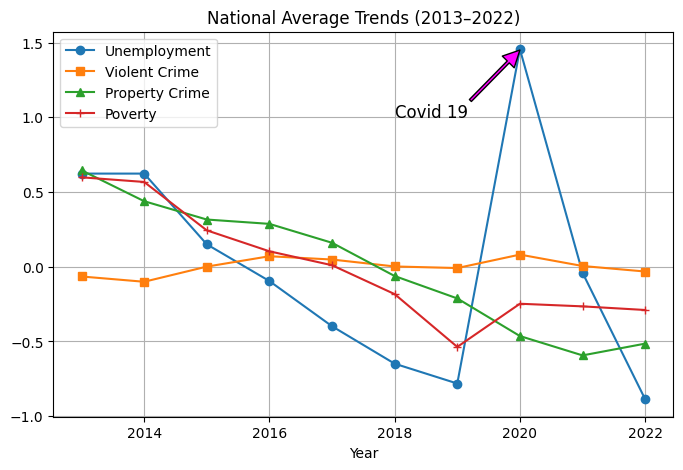

In [46]:
# نمودار کلی دیتای اصلی
numeric_cols=US_df.select_dtypes(include="number").columns
yearly=US_df.groupby("year")[numeric_cols].mean()
fig, ax=plt.subplots(figsize=(8,5))
ax.plot(yearly["year"], yearly["unemployment_rate"], marker="o", label="Unemployment")
ax.plot(yearly["year"], yearly["violent_crime_rate"], marker="s", label="Violent Crime")
ax.plot(yearly["year"], yearly["property_crime_rate"], marker="^", label="Property Crime")
ax.plot(yearly["year"], yearly["poverty_rate"], marker="+", label="Poverty")
ax.set_xlabel("Year")
ax.annotate("Covid 19", xytext=(2018,1),xy=(2020,1.45),arrowprops={"facecolor":"magenta","width":2},fontsize=12)
ax.legend()
ax.grid()
ax.set_title("National Average Trends (2013–2022)")
plt.show()

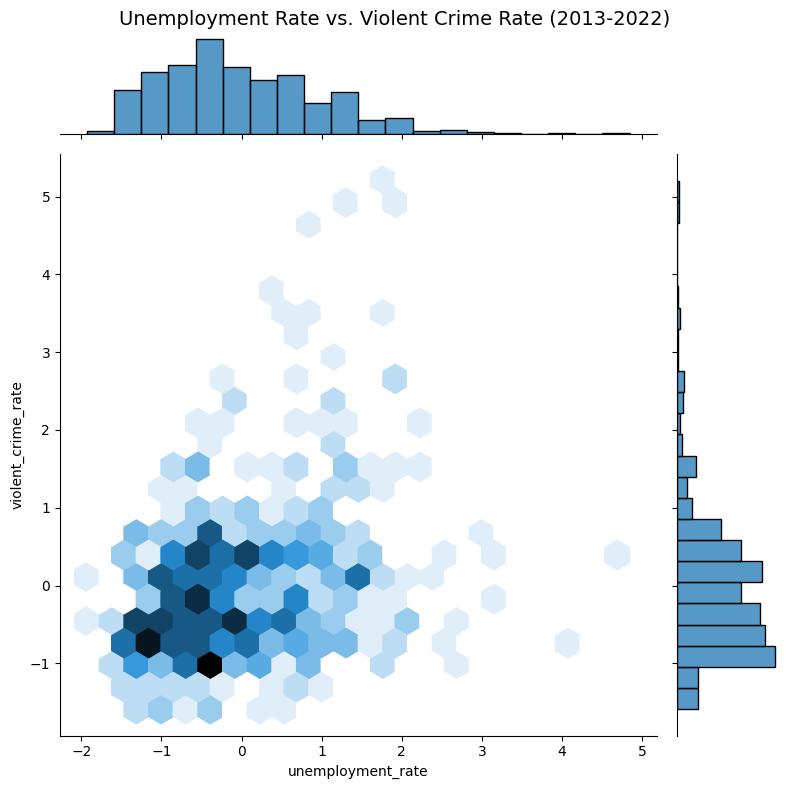

In [47]:
# مقایسه نرخ بیکاری و جرایم خشن
sns.jointplot(x="unemployment_rate",y="violent_crime_rate",height=8,data=US_df,kind="hex")
plt.suptitle("Unemployment Rate vs. Violent Crime Rate (2013-2022)", fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

In [48]:
from scipy.stats import pearsonr
p_coeff, p_value=pearsonr(US_df["unemployment_rate"], US_df["violent_crime_rate"])
print(f"p_coeff: {p_coeff:.2f}, p-value: {p_value:.2f}")

p_coeff: 0.30, p-value: 0.00


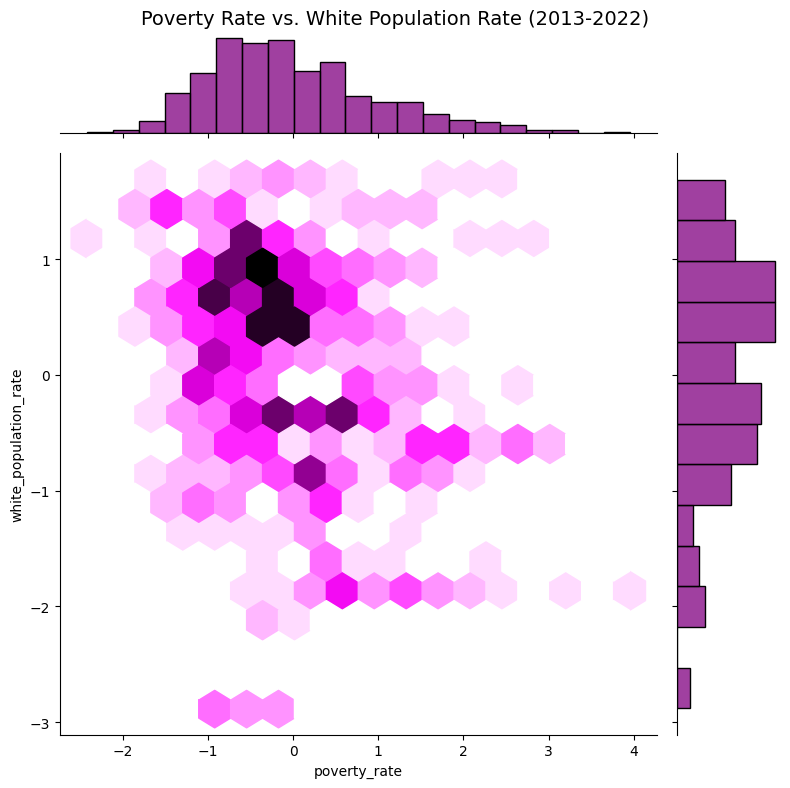

In [49]:
# مقایسه درصد فقر و جمعیت سفیدپوست
sns.jointplot(x="poverty_rate",y="white_population_rate",height=8,data=US_df,kind="hex",color="purple")
plt.suptitle("Poverty Rate vs. White Population Rate (2013-2022)", fontsize=14)
plt.tight_layout()
plt.subplots_adjust(top=0.95)
plt.show()

In [50]:
p_coeff, p_value=pearsonr(US_df["poverty_rate"], US_df["white_population_rate"])
print(f"p_coeff: {p_coeff:.2f}, p-value: {p_value:.2f}")

p_coeff: -0.26, p-value: 0.00


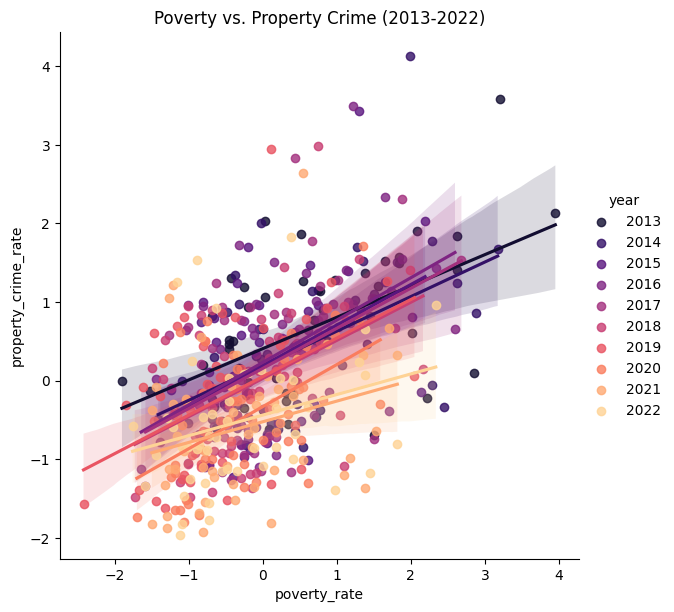

In [51]:
# مقایسه درصد فقر و نرخ جرایم علیه اموال
sns.lmplot(data=US_df, x="poverty_rate", y="property_crime_rate", hue="year", palette="magma", height=6)
plt.title("Poverty vs. Property Crime (2013-2022)")
plt.show()

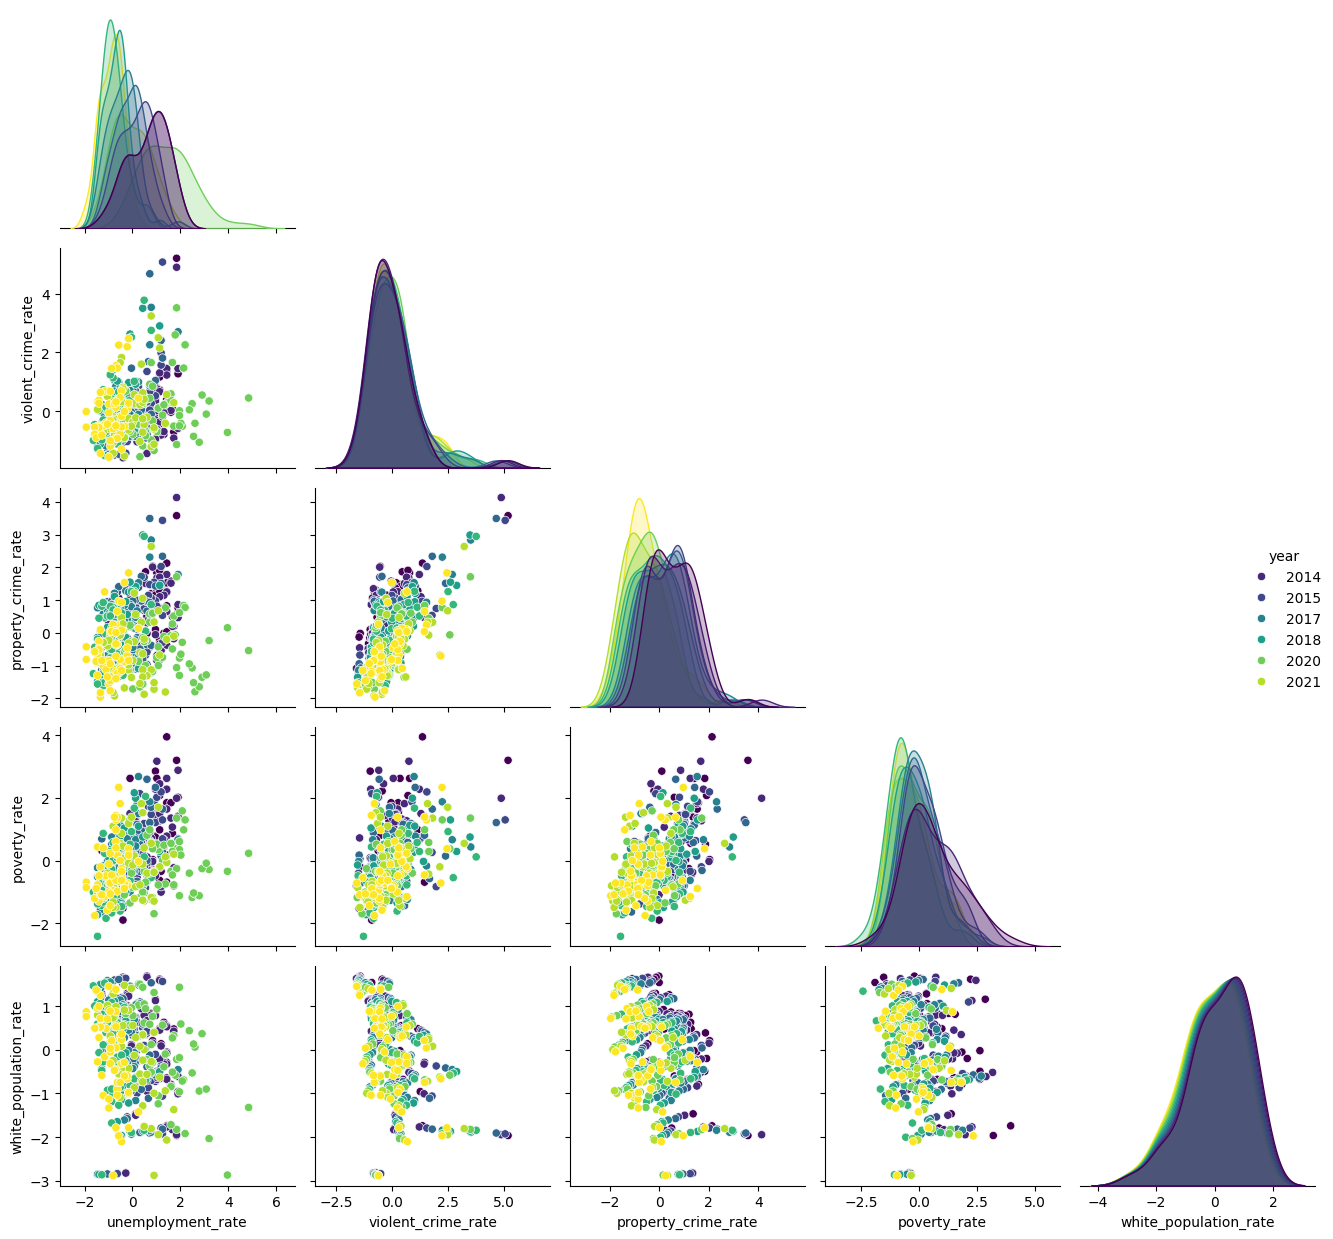

In [52]:
sns.pairplot(US_df, vars=["unemployment_rate","violent_crime_rate","property_crime_rate","poverty_rate","white_population_rate"],
             hue="year", palette="viridis", diag_kind="kde", corner=True)
plt.tight_layout()
plt.show()

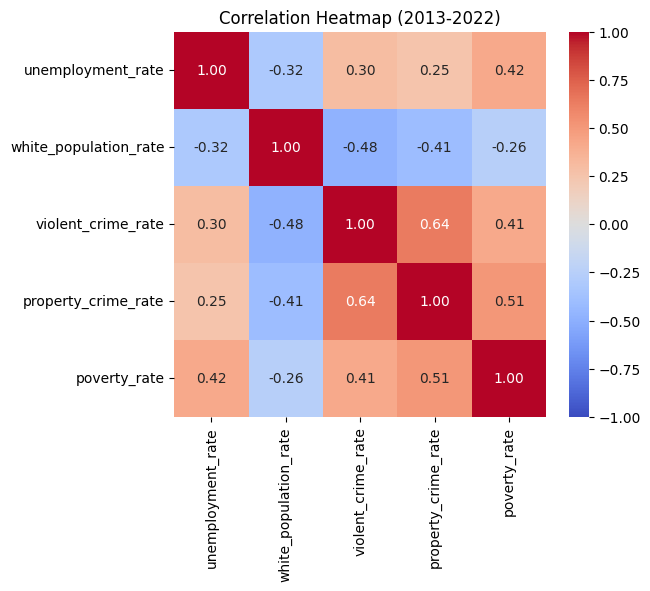

In [53]:
corr=US_df[["unemployment_rate","white_population_rate","violent_crime_rate","property_crime_rate","poverty_rate"]].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True,vmin=-1, vmax=1,fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (2013-2022)")
plt.show()

In [54]:
# پنج ایالت با بیشترین و کمترین متوسط جرایم خشن 
pivot1=US_df.pivot(index="state", columns="year", values="violent_crime_rate")
state_means=pivot1.mean(axis=1).sort_values(ascending=False)
print("Top 5 highest average violent-crime states:\n", state_means.head())
print("Top 5 lowest average violent-crime states:\n", state_means.tail())

Top 5 highest average violent-crime states:
 state
District of Columbia    3.988036
Alaska                  2.258005
New Mexico              2.036707
Tennessee               1.423412
Arkansas                1.106612
dtype: float64
Top 5 lowest average violent-crime states:
 state
Virginia        -0.971274
Connecticut     -0.990745
New Hampshire   -1.171521
Vermont         -1.240325
Maine           -1.495611
dtype: float64


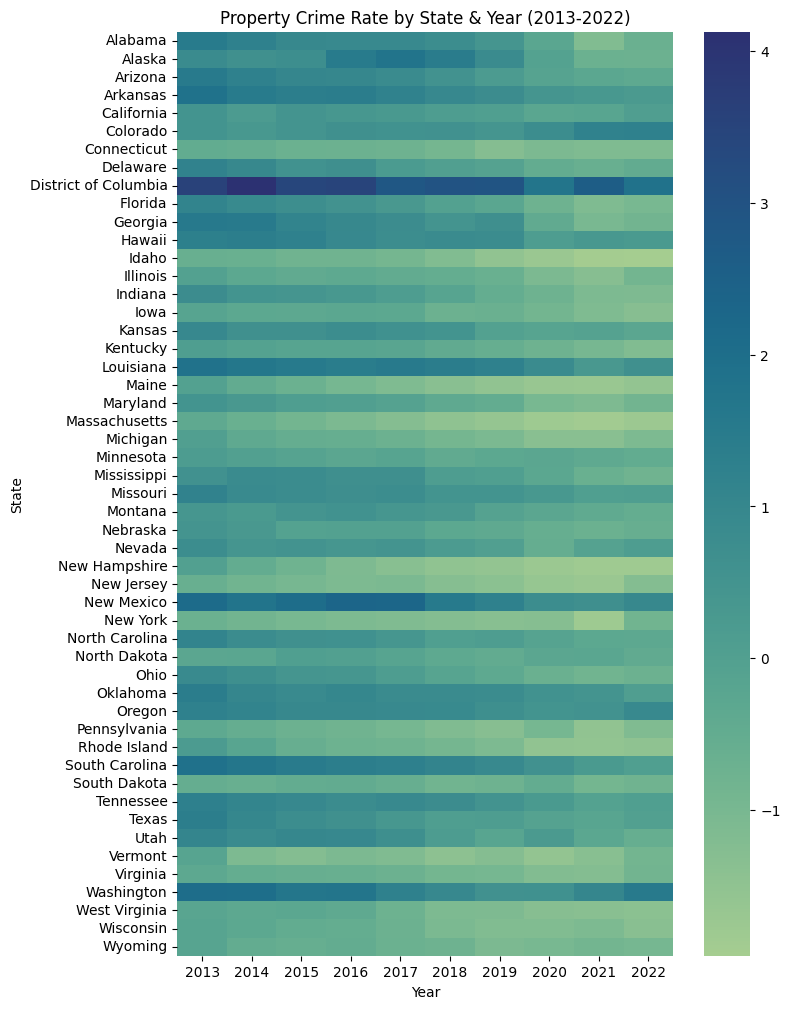

In [55]:
# مقایسه نرخ جرایم علیه اموال در همه ایالت ها در بازه ده ساله
pivot2=US_df.pivot(index="state", columns="year", values="property_crime_rate")
plt.figure(figsize=(8,12))
sns.heatmap(pivot2, cmap="crest")
plt.title("Property Crime Rate by State & Year (2013-2022)")
plt.xlabel("Year")
plt.ylabel("State")
plt.show()

In [56]:
# پنج ایالت با بیشترین و کمترین متوسط جرایم علیه اموال 
state_means=pivot2.mean(axis=1).sort_values(ascending=False)
print("Top 5 highest average property-crime states:\n", state_means.head())
print("Top 5 lowest average property-crime states:\n", state_means.tail())

Top 5 highest average property-crime states:
 state
District of Columbia    2.956605
New Mexico              1.579552
Washington              1.345834
Louisiana               1.249471
South Carolina          1.066809
dtype: float64
Top 5 lowest average property-crime states:
 state
New York        -1.130221
New Jersey      -1.184716
Idaho           -1.210138
New Hampshire   -1.217302
Massachusetts   -1.277549
dtype: float64


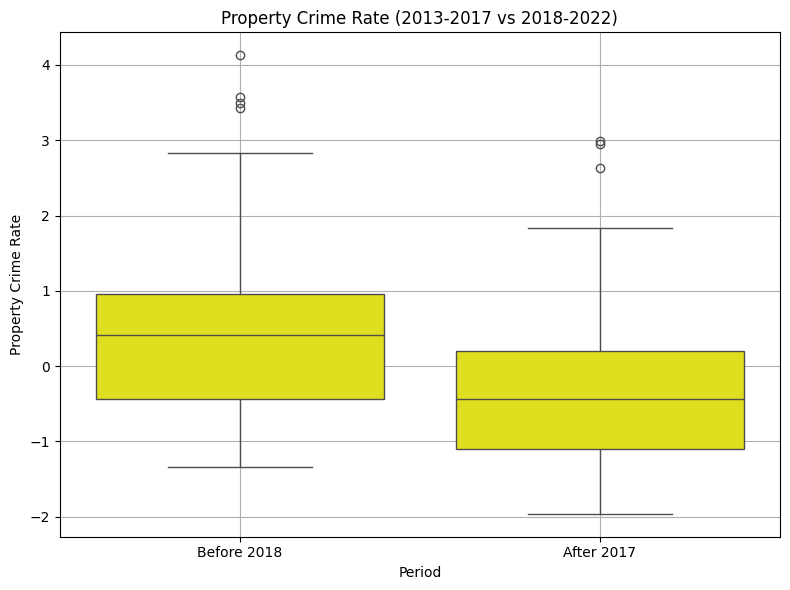

In [57]:
# مقایسه تغییرات میزان جرایم علیه اموال بین 5 سال اول و دوم
US_df["period"]=US_df["year"].apply(lambda x: "Before 2018" if x<=2017 else "After 2017")
plt.figure(figsize=(8, 6))
sns.boxplot(x="period", y="property_crime_rate", data=US_df,color="yellow")
plt.title("Property Crime Rate (2013-2017 vs 2018-2022)")
plt.ylabel("Property Crime Rate")
plt.xlabel("Period")
plt.grid()
plt.tight_layout()
plt.show()

In [58]:
# property_crime_rate_T_test
before=US_df[US_df["period"]=="Before 2018"]["property_crime_rate"]
after=US_df[US_df["period"]=="After 2017"]["property_crime_rate"]
t_stat, p_val=stats.ttest_ind(before, after)

print(f"T-stat: {t_stat:.2f}")
print(f"P-value: {p_val:.2f}")

T-stat: 8.96
P-value: 0.00


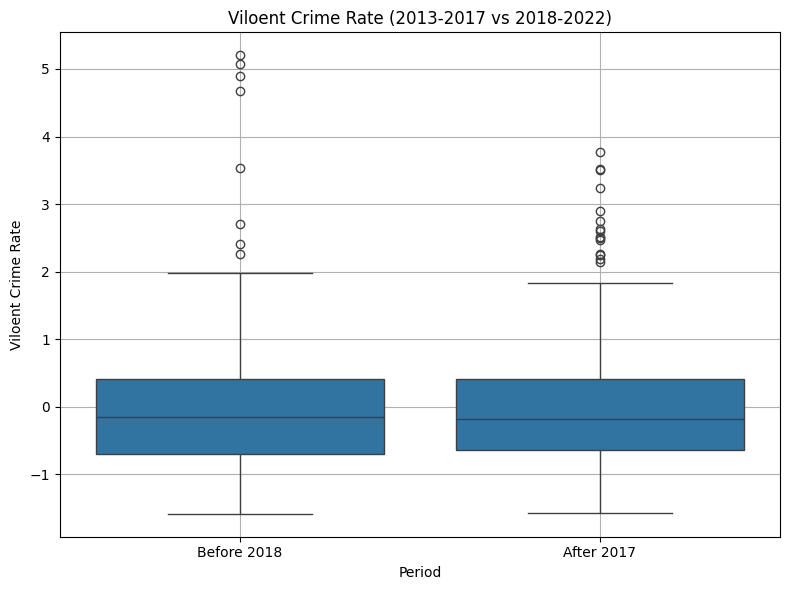

In [59]:
# # مقایسه تغییرات میزان جرایم خشن بین 5 سال اول و دوم
plt.figure(figsize=(8, 6))
sns.boxplot(x="period", y="violent_crime_rate", data=US_df)
plt.title("Viloent Crime Rate (2013-2017 vs 2018-2022)")
plt.ylabel("Viloent Crime Rate")
plt.xlabel("Period")
plt.grid()
plt.tight_layout()
plt.show()

In [60]:
# violent_crime_rate_T_test
before=US_df[US_df["period"]=="Before 2018"]["violent_crime_rate"]
after=US_df[US_df["period"]=="After 2017"]["violent_crime_rate"]
t_stat, p_val=stats.ttest_ind(before, after)

print(f"T-stat: {t_stat:.2f}")
print(f"P-value: {p_val:.2f}")

T-stat: -0.21
P-value: 0.83


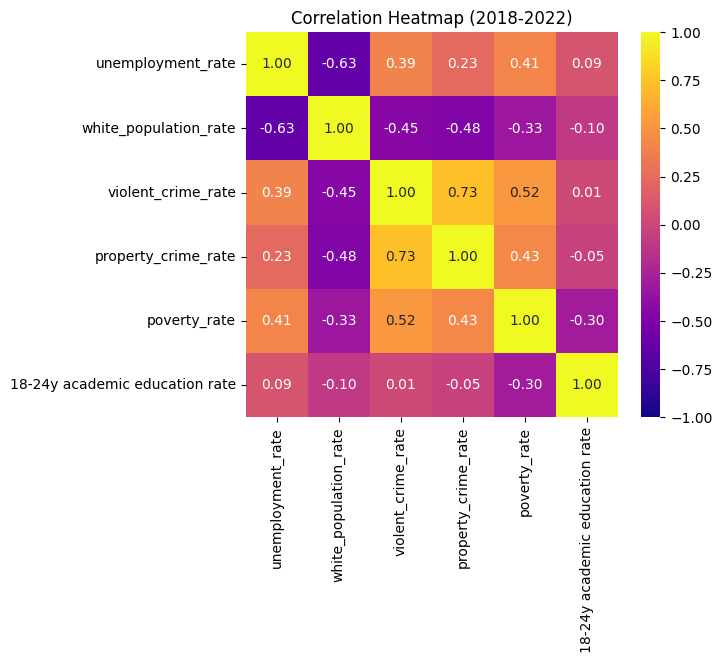

In [61]:
# هیت مپ 2018-2022 با در نظر گرفتن نرخ تحصیلات آکادمیک
second_corr=second_half_df[["unemployment_rate","white_population_rate","violent_crime_rate","property_crime_rate","poverty_rate","18-24y academic education rate"]].corr()
plt.figure(figsize=(6,5))
sns.heatmap(second_corr, annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="plasma")
plt.title("Correlation Heatmap (2018-2022)")
plt.show()

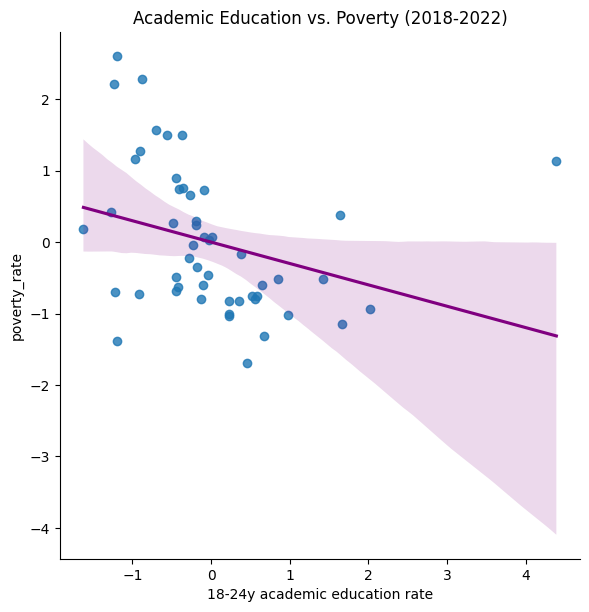

In [62]:
# مقایسه نرخ تحصیلات آکادمیک و فقر
sns.lmplot(data=second_half_df, x="18-24y academic education rate", y="poverty_rate", line_kws={"color": "purple"}, height=6)
plt.title("Academic Education vs. Poverty (2018-2022)")
plt.show()